# TwoTank — Stage 4b — Symbolic-Jacobian Safe Adaptation (Barrier, Generalized)

Verify and benchmark analytic safety sensitivities.


## 1. Set up the system and load the stage config

Load dependencies and configuration.


In [1]:
"""Boilerplate: make the in-repo `sdpc` package importable and resolve this system."""
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_p = Path.cwd()
while not (_p / "src" / "sdpc").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import torch
from sdpc.config import load_config
from sdpc.registry import make_system

SYSTEM = "twotank"
device = torch.device("cpu")
system = make_system(SYSTEM, device=device)
CONFIGS = Path.cwd().parent / "configs"
RESULTS = Path.cwd().parent / "results"

print(f"System        : {SYSTEM}")
print(f"State dim nx  : {system.nx}")
print(f"Control dim nu: {system.nu}")
print(f"Sample time ts: {system.ts}")
print(f"Input bounds  : [{system.umin}, {system.umax}]")
print(f"State bounds  : [{system.xmin}, {system.xmax}]")
print(f"Discrete model: {system.is_discrete}")


System        : twotank
State dim nx  : 2
Control dim nu: 2
Sample time ts: 1.0
Input bounds  : [0.0, 1.0]
State bounds  : [0.0, 1.0]
Discrete model: False


In [2]:
cfg = load_config(CONFIGS / 'safe.yaml')
print('Resolved safe-adaptation config:')
for k, v in cfg.items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')

Resolved safe-adaptation config:
  seed: 0
  nsteps: 1500
  action_scale: 1.0
  xmin: 0.2
  xmax: 0.8
  initial_fraction_range: [0.2, 0.7]
  reference: {'kind': 'equal', 'relative_to_bounds': True, 'levels': [[0.8, 0.8], [0.25, 0.25], [0.45, 0.45], [0.8, 0.8], [0.35, 0.35]]}
  perturbation: {'c1': 0.14, 'c2': 0.03}
  weights: {'Q_con_x': 50.0, 'Q_con_du': 1.0}
  bands: {'box': 0.06, 'du': 0.0}
  du_max: 1.0
  safe: {'horizon': 30, 'gamma_ref': 2.0, 'gamma_safe': 0.05, 'clip_update': 1.0, 'safety_grad_max_norm': 1.0, 'max_safety_iters': 15, 'barrier_kind': 'squared_hinge', 'ref_backend': 'symbolic', 'safety_backend': 'symbolic', 'safety_action_gradient': 'straight_through', 'integration_method': 'rk4', 'adaptive_gamma': False}
  psf: {'horizon': 30, 'gamma_ref': 2.0, 'clip_update': 1.0, 'action_scale': 1.0, 'integration_method': 'rk4', 'adaptive_gamma': False, 'buffers': {'box': 0.06, 'du': 0.0}, 'tail_weight': 1e-06, 'smooth_weight': 0.001, 'max_iter': 500, 'tol': 1e-06}


## 2. Load the trained policy and build the safety specification

Restore the required checkpoints.


In [3]:
from sdpc.sindy import load_model
from sdpc.adaptation.analytic import sindy_step

# Sparse policy
from sdpc.io import find_policy_checkpoint
policy_path = find_policy_checkpoint(RESULTS, cfg)
policy = load_model(policy_path, device=device)

# Exact perturbed dynamics in SINDy form. This is the model used for safety
# prediction and analytic derivatives, so the comparison is not polluted by
# system-ID error from the trained nominal dynamics checkpoint.
sindy = system.perturbed_sindy_model(cfg)

def make_pred_plant(method='rk4'):
    return lambda x, u: sindy_step(sindy, x, u, system=system, method=method)

pred_plant = make_pred_plant(cfg.get('safe', {}).get('integration_method', 'rk4'))

# Real deployment plant with configured mismatch; this should match pred_plant
# when method='rk4' for continuous systems, and exactly for discrete systems.
plant = system.perturbed_plant(cfg)
spec = system.safety_specs(cfg)

print('Policy checkpoint      :', policy_path)
print('Exact perturbed dynamics: SINDy-style model from system.perturbed_sindy_model(cfg)')
print('Safety constraints     :', [c.name for c in spec.state_constraints])
print('Control-rate limit     :', spec.control_rate is not None)


Policy checkpoint      : /Users/alireza/Documents/PythonProject/gptSparseDPC/SparseDPC/6_Relative_Degree_One/TwoTank/results/models/policies/sd_dpc/run_1/saved_models/policy_sparse.pt
Exact perturbed dynamics: SINDy-style model from system.perturbed_sindy_model(cfg)
Safety constraints     : ['x0_min', 'x0_max', 'x1_min', 'x1_max']
Control-rate limit     : True


## 3. Build the symbolic safety Jacobian and verify it against autograd

Build and verify the sensitivities.


In [4]:
import copy
from sdpc.adaptation import SymbolicSafetyJacobian
from sdpc.adaptation.rollout import predict_rollout
from sdpc.adaptation.reference import zero_xi_grads
from sdpc.adaptation.barrier import rollout_barrier_loss, rollout_box_relu_loss, rollout_box_barrier_loss
from sdpc.eval import sample_scenario

safe_cfg = cfg.get('safe', {})
barrier_kind = safe_cfg.get('barrier_kind', 'squared_hinge')
barrier_eps = safe_cfg.get('barrier_eps', 1e-6)
horizon = safe_cfg.get('horizon', 20)
action_scale = safe_cfg.get('action_scale', cfg.get('action_scale', 1.0))

# Use an unsafe but positive state. Starting below zero makes TwoTank sqrt features
# non-smooth at the clamp and can produce meaningless/huge analytic sqrt sensitivities.
benchmark_data = sample_scenario(system, cfg, cfg.get('seed', 0), device)
xlo, xhi = map(float, benchmark_data['state_bounds'].detach().cpu().tolist())
benchmark_ref = benchmark_data['r'][:, :1, :]
x0_bad = torch.full((1, system.nx), xhi + 0.1 * (xhi - xlo), dtype=torch.float32, device=device)
r_horizon = benchmark_ref.expand(1, horizon, system.nx).contiguous()

policy_ag, policy_sym = copy.deepcopy(policy), copy.deepcopy(policy)

# (a) autograd baseline: backprop through the unrolled prediction graph.
zero_xi_grads(policy_ag)
x_roll, u_roll = predict_rollout(
    policy_ag, pred_plant, x0_bad, r_horizon, horizon,
    umin=system.umin, umax=system.umax, action_scale=action_scale, grad=True,
)
# For gradient comparison, exclude x0. It is fixed, so d x0 / dXi = 0; symbolic
# sensitivity correctly accumulates only future-state contributions x1..xN.
loss_ag_all, _, _ = rollout_barrier_loss(
    x_roll, spec, kind=barrier_kind, eps=barrier_eps, u_traj=u_roll,
)
loss_ag, _, _ = rollout_barrier_loss(
    x_roll[:, 1:, :], spec, kind=barrier_kind, eps=barrier_eps, u_traj=u_roll,
)
print('barrier loss including x0:', float(loss_ag_all))
print('future-state barrier loss for gradient check:', float(loss_ag))
loss_ag.backward()
raw_ag = [(-p.grad.detach().clone() if p.grad is not None else torch.zeros_like(p)) for p in policy_ag.Xi]
zero_xi_grads(policy_ag)

# (b) analytic symbolic backend: no-grad rollout + forward sensitivity recursion.
with torch.no_grad():
    x_roll2, u_roll2 = predict_rollout(
        policy_sym, pred_plant, x0_bad, r_horizon, horizon,
        umin=system.umin, umax=system.umax, action_scale=action_scale, grad=False,
    )
safety_jac = SymbolicSafetyJacobian(
    sindy, policy_sym, system.umin, system.umax,
    system=system, action_scale=action_scale,
    integration_method=safe_cfg.get('integration_method', 'rk4'),
)
raw_sym, loss_sym = safety_jac.rollout_sensitivity_grad(
    x_roll2, u_roll2, r_horizon, spec, kind=barrier_kind, eps=barrier_eps,
)
print('symbolic-reported future-state barrier loss:', loss_sym)
print('max rollout disagreement:', float((x_roll.detach() - x_roll2).abs().max()))


barrier loss including x0: 8.248289108276367
future-state barrier loss for gradient check: 7.528289318084717
symbolic-reported future-state barrier loss: 7.528289318084717
max rollout disagreement: 0.0


In [5]:
def _safe_cos_rel(a, s):
    a_flat, s_flat = a.flatten(), s.flatten()
    an, sn = a_flat.norm(), s_flat.norm()
    if not torch.isfinite(s_flat).all():
        return float('nan'), float('nan')
    if an.item() == 0.0 and sn.item() == 0.0:
        return 1.0, 0.0
    if an.item() == 0.0 or sn.item() == 0.0:
        return 0.0, float('inf')
    cos = torch.nn.functional.cosine_similarity(a_flat, s_flat, dim=0).item()
    rel = (a - s).norm().item() / (an.item() + 1e-12)
    return cos, rel

print(f"{'output':>8} {'autograd norm':>16} {'symbolic norm':>16} "
      f"{'cos_sim':>10} {'rel_diff':>10}")
for k, (a, s) in enumerate(zip(raw_ag, raw_sym)):
    cos, rel = _safe_cos_rel(a, s)
    print(f'{k:>8} {a.norm().item():>16.4e} {s.norm().item():>16.4e} '
          f'{cos:>10.6f} {rel:>10.2e}')


  output    autograd norm    symbolic norm    cos_sim   rel_diff
       0       1.5404e+01       1.5404e+01   1.000000   6.39e-08
       1       1.6900e-02       1.6900e-02   1.000000   2.34e-07


## 4. Run full safe adaptation with each backend and compare

Compare both safety backends.


In [6]:
import time
from sdpc.eval import sample_scenario
from sdpc.adaptation import SafeAdaptationConfig, run_safe_adaptation

data = sample_scenario(system, cfg, cfg.get('seed', 0), device)

constraint_modes = [
    ('boxrelu', 'box_relu_constraints'),
    ('boxbarrier', 'box_barrier_constraints'),
]
integrator_modes = ['rk4', 'euler']
backend_modes = ['autograd', 'symbolic']

run_modes = [
    {
        'name': f'{backend}_{cname}_{method}',
        'backend': backend,
        'constraint': cname,
        'barrier': bkind,
        'method': method,
    }
    for cname, bkind in constraint_modes
    for method in integrator_modes
    for backend in backend_modes
]

results = {}
run_wall = {}
for mode in run_modes:
    pol = copy.deepcopy(policy)
    safe_run_cfg = {
        **cfg.get('safe', {}),
        'safety_backend': mode['backend'],
        'barrier_kind': mode['barrier'],
        'integration_method': mode['method'],
    }
    safe_run_cfg.setdefault('action_scale', cfg.get('action_scale', 1.0))
    scfg = SafeAdaptationConfig(**safe_run_cfg)
    pred = make_pred_plant(mode['method'])
    t0 = time.perf_counter()
    results[mode['name']] = run_safe_adaptation(
        pol, plant, data, spec, scfg,
        umin=system.umin, umax=system.umax,
        pred_plant=pred,
        derivative_model=sindy,
        system=system,
    )
    elapsed = time.perf_counter() - t0
    run_wall[mode['name']] = elapsed
    logs = results[mode['name']]['logs']
    n_safe = sum(l['predicted_safe'] for l in logs)
    total_iters = sum(l['safety_iters'] for l in logs)
    print(f"[{mode['name']:28s}] wall={elapsed:7.3f}s  "
          f"predicted-safe={n_safe}/{len(logs)}  total safety iters={total_iters}")

print('\nFull safe-adaptation wall-time speedups, paired by constraint and integrator')
print(f"{'constraint':>12} {'integrator':>10} {'autograd (s)':>12} {'symbolic (s)':>12} {'speedup':>9} {'max |dx|':>11} {'max |du|':>11}")
for cname, _ in constraint_modes:
    for method in integrator_modes:
        ag = f'autograd_{cname}_{method}'
        sy = f'symbolic_{cname}_{method}'
        ag_t = run_wall[ag]
        sy_t = run_wall[sy]
        x_diff = (results[ag]['x_traj'] - results[sy]['x_traj']).abs().max().item()
        u_diff = (results[ag]['u_traj'] - results[sy]['u_traj']).abs().max().item()
        print(f'{cname:>12} {method:>10} {ag_t:>12.4f} {sy_t:>12.4f} {ag_t / max(sy_t, 1e-9):>8.2f}x {x_diff:>11.3e} {u_diff:>11.3e}')


[autograd_boxrelu_rk4        ] wall= 15.968s  predicted-safe=1500/1500  total safety iters=6
[symbolic_boxrelu_rk4        ] wall= 12.094s  predicted-safe=1500/1500  total safety iters=11
[autograd_boxrelu_euler      ] wall=  7.032s  predicted-safe=1500/1500  total safety iters=6
[symbolic_boxrelu_euler      ] wall=  5.702s  predicted-safe=1500/1500  total safety iters=11



KeyboardInterrupt



## 5. One-step safety-correction wall-clock time

Measure safety-gradient runtime.


   5 |    boxrelu |   rk4 | autograd=0.003739s | symbolic=0.002380s | speedup=1.57x
   5 |    boxrelu | euler | autograd=0.001288s | symbolic=0.001071s | speedup=1.20x
   5 | boxbarrier |   rk4 | autograd=0.003202s | symbolic=0.002673s | speedup=1.20x
   5 | boxbarrier | euler | autograd=0.001397s | symbolic=0.001374s | speedup=1.02x
  10 |    boxrelu |   rk4 | autograd=0.006349s | symbolic=0.003418s | speedup=1.86x
  10 |    boxrelu | euler | autograd=0.002379s | symbolic=0.001669s | speedup=1.43x
  10 | boxbarrier |   rk4 | autograd=0.008953s | symbolic=0.004635s | speedup=1.93x
  10 | boxbarrier | euler | autograd=0.003715s | symbolic=0.002071s | speedup=1.79x
  20 |    boxrelu |   rk4 | autograd=0.014246s | symbolic=0.005939s | speedup=2.40x
  20 |    boxrelu | euler | autograd=0.005618s | symbolic=0.003029s | speedup=1.85x
  20 | boxbarrier |   rk4 | autograd=0.013789s | symbolic=0.006228s | speedup=2.21x
  20 | boxbarrier | euler | autograd=0.005578s | symbolic=0.003297s | speedu

,horizon,constraint,integrator,autograd_time_s,symbolic_time_s,speedup
0,5,boxrelu,rk4,0.003739,0.002380,1.57
1,5,boxrelu,euler,0.001288,0.001071,1.20
2,5,boxbarrier,rk4,0.003202,0.002673,1.20
3,5,boxbarrier,euler,0.001397,0.001374,1.02
4,10,boxrelu,rk4,0.006349,0.003418,1.86
5,10,boxrelu,euler,0.002379,0.001669,1.43
6,10,boxbarrier,rk4,0.008953,0.004635,1.93
7,10,boxbarrier,euler,0.003715,0.002071,1.79
8,20,boxrelu,rk4,0.014246,0.005939,2.40
9,20,boxrelu,euler,0.005618,0.003029,1.85


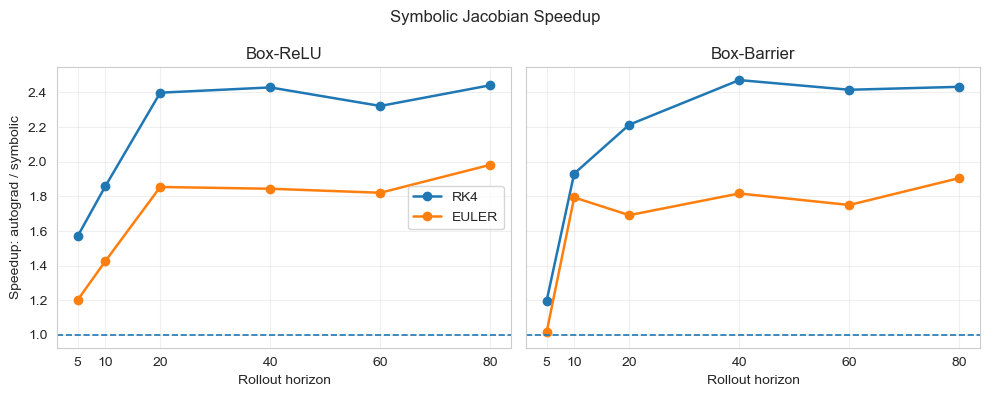

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import statistics
# Run only Box-ReLU and Box-Barrier benchmarks
BOX_RELU_KIND = 'box_relu_constraints'
BOX_BARRIER_KIND = 'box_barrier_constraints'

def _sync():
    if torch.cuda.is_available() and device.type == 'cuda':
        torch.cuda.synchronize()

def _safety_loss_for_kind(x_r, u_r, penalty_kind):
    if penalty_kind == BOX_RELU_KIND:
        loss, _ = rollout_box_relu_loss(x_r, spec, include_x0=False)
        return loss
    if penalty_kind == BOX_BARRIER_KIND:
        loss, _ = rollout_box_barrier_loss(
            x_r, spec, barrier_kind='squared_hinge', eps=barrier_eps, include_x0=False,
        )
        return loss
    loss, _, _ = rollout_barrier_loss(
        x_r, spec, kind=penalty_kind, eps=barrier_eps, u_traj=u_r,
    )
    return loss

def time_backend(backend, horizon, *, penalty_kind, method, n_rep=20, warmup=5):
    r_h = benchmark_ref.expand(1, horizon, system.nx).contiguous()
    pol = copy.deepcopy(policy)
    pred = make_pred_plant(method)

    # Build the Jacobian object once, outside timing. The timed path includes one
    # rollout for both methods: autograd uses grad=True and backward only if unsafe;
    # symbolic uses grad=False and then forward sensitivity only if unsafe.
    sj = None
    if backend == 'symbolic':
        sj = SymbolicSafetyJacobian(
            sindy, pol, system.umin, system.umax,
            system=system, action_scale=action_scale,
            integration_method=method,
        )

    def once():
        if backend == 'symbolic':
            with torch.no_grad():
                x_r, u_r = predict_rollout(
                    pol, pred, x0_bad, r_h, horizon,
                    umin=system.umin, umax=system.umax,
                    action_scale=action_scale, grad=False,
                )
                loss = _safety_loss_for_kind(x_r, u_r, penalty_kind)
            if float(loss.detach().cpu().item()) <= safe_cfg.get('safety_loss_tol', 1e-10):
                return [torch.zeros_like(p) for p in pol.Xi], float(loss.detach().cpu().item())
            return sj.rollout_sensitivity_grad(
                x_r, u_r, r_h, spec, kind=penalty_kind, eps=barrier_eps,
            )

        zero_xi_grads(pol)
        x_r, u_r = predict_rollout(
            pol, pred, x0_bad, r_h, horizon,
            umin=system.umin, umax=system.umax,
            action_scale=action_scale, grad=True,
        )
        loss = _safety_loss_for_kind(x_r, u_r, penalty_kind)
        if float(loss.detach().cpu().item()) > safe_cfg.get('safety_loss_tol', 1e-10):
            loss.backward()
            raw = [(-p.grad.detach().clone() if p.grad is not None else torch.zeros_like(p)) for p in pol.Xi]
        else:
            raw = [torch.zeros_like(p) for p in pol.Xi]
        zero_xi_grads(pol)
        return raw, float(loss.detach().cpu().item())

    for _ in range(warmup):
        once()
    times = []
    for _ in range(n_rep):
        _sync()
        t0 = time.perf_counter()
        once()
        _sync()
        times.append(time.perf_counter() - t0)
    return statistics.median(times)
selected_bench_specs = [
    ('boxrelu', BOX_RELU_KIND),
    ('boxbarrier', BOX_BARRIER_KIND),
]

horizons = [5, 10, 20, 40, 60, 80]
integrators = ['rk4', 'euler']

benchmark_results = []

for horizon in horizons:
    for constraint_name, penalty_kind in selected_bench_specs:
        for method in integrators:
            autograd_time = time_backend(
                'autograd',
                horizon,
                penalty_kind=penalty_kind,
                method=method,
            )

            symbolic_time = time_backend(
                'symbolic',
                horizon,
                penalty_kind=penalty_kind,
                method=method,
            )

            speedup = autograd_time / max(symbolic_time, 1e-9)

            benchmark_results.append({
                'horizon': horizon,
                'constraint': constraint_name,
                'integrator': method,
                'autograd_time_s': autograd_time,
                'symbolic_time_s': symbolic_time,
                'speedup': speedup,
            })

            print(
                f'{horizon:>4} | '
                f'{constraint_name:>10} | '
                f'{method:>5} | '
                f'autograd={autograd_time:.6f}s | '
                f'symbolic={symbolic_time:.6f}s | '
                f'speedup={speedup:.2f}x'
            )

results_df = pd.DataFrame(benchmark_results)

display(
    results_df.round({
        'autograd_time_s': 6,
        'symbolic_time_s': 6,
        'speedup': 2,
    })
)

# ---------------------------------------------------------
# Two compact subplots: Box-ReLU and Box-Barrier speedup
# ---------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    sharex=True,
    sharey=True,
)

for ax, constraint_name in zip(
    axes,
    ['boxrelu', 'boxbarrier'],
):
    subset = results_df[
        results_df['constraint'] == constraint_name
    ]

    for integrator in integrators:
        curve = subset[
            subset['integrator'] == integrator
        ].sort_values('horizon')

        ax.plot(
            curve['horizon'],
            curve['speedup'],
            marker='o',
            linewidth=1.8,
            label=integrator.upper(),
        )

    ax.axhline(
        1.0,
        linestyle='--',
        linewidth=1.2,
    )

    ax.set_title(
        'Box-ReLU' if constraint_name == 'boxrelu'
        else 'Box-Barrier'
    )
    ax.set_xlabel('Rollout horizon')
    ax.set_xticks(horizons)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Speedup: autograd / symbolic')
axes[0].legend()

fig.suptitle('Symbolic Jacobian Speedup')
plt.tight_layout()
plt.show()

## 6. Trajectory comparison

Compare the executed trajectories.


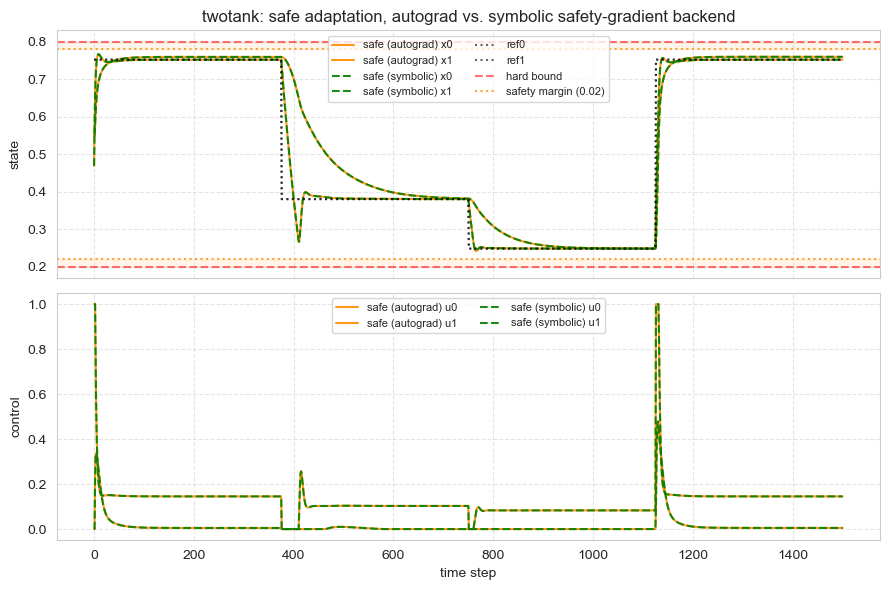

In [8]:
from sdpc.plotting import plot_states_and_controls
import matplotlib.pyplot as plt

plot_states_and_controls(
    [
        {'x': results['autograd_boxbarrier_rk4']['x_traj'], 'u': results['autograd_boxbarrier_rk4']['u_traj'],
         'label': 'safe (autograd)', 'color': 'darkorange'},
        {'x': results['symbolic_boxbarrier_rk4']['x_traj'], 'u': results['symbolic_boxbarrier_rk4']['u_traj'],
         'label': 'safe (symbolic)', 'color': 'green', 'linestyle': '--'},

        # {'x': results['autograd_boxbarrier_euler']['x_traj'], 'u': results['autograd_boxbarrier_euler']['u_traj'],
        #  'label': 'safe (autograd)', 'color': 'darkorange'},
        # {'x': results['symbolic_boxbarrier_euler']['x_traj'], 'u': results['symbolic_boxbarrier_euler']['u_traj'],
        #  'label': 'safe (symbolic)', 'color': 'green', 'linestyle': '--'},

        # {'x': results['autograd_barrier_euler']['x_traj'], 'u': results['autograd_barrier_euler']['u_traj'],
        #  'label': 'safe (autograd)', 'color': 'darkorange'},
        # {'x': results['symbolic_barrier_euler']['x_traj'], 'u': results['symbolic_barrier_euler']['u_traj'],
        #  'label': 'safe (symbolic)', 'color': 'green', 'linestyle': '--'},

        # {'x': results['autograd_relu_euler']['x_traj'], 'u': results['autograd_relu_euler']['u_traj'],
        #  'label': 'safe (autograd)', 'color': 'darkorange'},
        # {'x': results['symbolic_relu_euler']['x_traj'], 'u': results['symbolic_relu_euler']['u_traj'],
        #  'label': 'safe (symbolic)', 'color': 'green', 'linestyle': '--'},

        # {'x': results['autograd_boxrelu_rk4']['x_traj'], 'u': results['autograd_boxrelu_rk4']['u_traj'],
        #  'label': 'safe (autograd)', 'color': 'darkorange'},
        # {'x': results['symbolic_boxrelu_rk4']['x_traj'], 'u': results['symbolic_boxrelu_rk4']['u_traj'],
        #  'label': 'safe (symbolic)', 'color': 'green', 'linestyle': '--'},
    ],
    r_traj=data['r'], xmin=float(data['state_bounds'][0]), xmax=float(data['state_bounds'][1]),
    state_margin=float(cfg.get('bands', {}).get('box', 0.0)),
    title=f'{SYSTEM}: safe adaptation, autograd vs. symbolic safety-gradient backend',
)
plt.show()

In [ ]:
results.keys()

**Takeaway.** The symbolic safety backend now uses analytic SINDy/policy derivatives and forward sensitivity recursion, so the benchmark compares a no-autograd safety-gradient...
